# MONAI UNet Prediction

Load a trained MONAI UNet model and predict on the middle 2D slice of a 3D image.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from napari_ai_lab.models import ImageDataModel
from napari_ai_lab.Segmenters.GlobalSegmenters.MonaiUNetSegmenter import (
    MonaiUNetSegmenter,
)
from napari_ai_lab.utilities.dl_util import normalize_percentile

print("✅ Libraries imported successfully")

c:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\pixi\microsam_cellposesam_czi\.pixi\envs\default\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported successfully


## 1. Setup Project and Load Image

In [2]:
# Setup paths
project_path = Path(r"C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\vessels_large")
image_data_model = ImageDataModel(parent_directory=project_path)

# Load first image (3D volume)
image = image_data_model.load_image(0)

print(f"Project path: {project_path}")
print(f"Image shape: {image.shape}")
print(f"Image dtype: {image.dtype}")
print(f"Image value range: [{image.min()}, {image.max()}]")

Loading image: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\vessels_large\Test lightsheet.czi
Loaded image shape: (395, 3080, 2868)
Axis types: ZYX
Project path: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\vessels_large
Image shape: (395, 3080, 2868)
Image dtype: uint16
Image value range: [130, 36352]


## 2. Load Trained Model

In [3]:
segmenter = MonaiUNetSegmenter()

models_dir = image_data_model.get_models_directory()
model_name = "testmay11_2.pth"
model_file_path = models_dir / model_name

segmenter.load_model(str(model_file_path))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
print(f"Number of classes: {segmenter.num_classes}")

📁 Loading MONAI UNet model from: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\vessels_large\models\testmay11_2.pth
✅ Successfully loaded MONAI UNet model from: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\vessels_large\models\testmay11_2.pth
   Model type: <class 'monai.networks.nets.unet.UNet'>
   Loaded downsize_factor=1 from testmay11_2.json
Using device: cuda
Number of classes: 2


## 3. Extract Middle Slice and Predict

In [4]:
def simple_predict_logits(model, patch, device='cpu', normalize=False):
    """Simple prediction function that returns logits for each class.
    
    Args:
        model: The trained model
        patch: Input patch (already normalized if from training patches)
        device: Device to run inference on ('cpu' or 'cuda')
        normalize: Whether to normalize the patch (default False, patches are already normalized)
    """
    # Optionally normalize the patch
    if normalize:
        patch_normalized = normalize_percentile(patch, p_low=0.0, p_high=1.0)
    else:
        patch_normalized = patch

    # Add batch and channel dimensions: [H, W] -> [1, 1, H, W]
    if len(patch_normalized.shape) == 2:
        patch_tensor = torch.from_numpy(patch_normalized).unsqueeze(0).unsqueeze(0).float()
    elif len(patch_normalized.shape) == 3 and patch_normalized.shape[0] == 1:
        patch_tensor = torch.from_numpy(patch_normalized).unsqueeze(0).float()
    else:
        patch_tensor = torch.from_numpy(patch_normalized).float()

    # Move to device
    patch_tensor = patch_tensor.to(device)
    model = model.to(device)
    model.eval()

    # Predict
    with torch.no_grad():
        output = model(patch_tensor)  # [1, num_classes, H, W]

        # Get logits for each class
        logits = output.squeeze(0).cpu().numpy()  # [num_classes, H, W]

    probabilities = torch.softmax(output, dim=1)
    predicted_classes = torch.argmax(probabilities, dim=1).cpu().numpy().squeeze() + 1

    return logits, predicted_classes

# Extract middle slice from 3D volume (assume first axis is Z)
mid_z = image.shape[0] // 2
middle_slice = image[mid_z]

# Crop a 1024x1024 region starting at (row=1500, col=100)
crop_row, crop_col, crop_size = 100, 100, 2048
cropped_slice = middle_slice[crop_row:crop_row + crop_size, crop_col:crop_col + crop_size]

print('cropped_slice min/max:', cropped_slice.min(), cropped_slice.max())

print(f"3D image shape: {image.shape}")
print(f"Middle slice index (Z={mid_z}): shape={middle_slice.shape}")
print(f"Cropped slice shape: {cropped_slice.shape} (row={crop_row}, col={crop_col}, size={crop_size})")
print(f"Crop value range: [{cropped_slice.min()}, {cropped_slice.max()}]")

# Normalize the cropped slice
slice_normalized = normalize_percentile(cropped_slice.astype(np.float32), percentile_low=1, percentile_high=99)

# Predict
logits, predicted_classes = simple_predict_logits(segmenter.model, slice_normalized, device=device, normalize=False)

num_classes = logits.shape[0]
print("\nPrediction complete!")
print(f"Logits shape: {logits.shape}")
print(f"Predicted classes unique values: {np.unique(predicted_classes)}")


cropped_slice min/max: 172 9063
3D image shape: (395, 3080, 2868)
Middle slice index (Z=197): shape=(3080, 2868)
Cropped slice shape: (2048, 2048) (row=100, col=100, size=2048)
Crop value range: [172, 9063]

Prediction complete!
Logits shape: (4, 2048, 2048)
Predicted classes unique values: [4]


## 4. Visualize Results

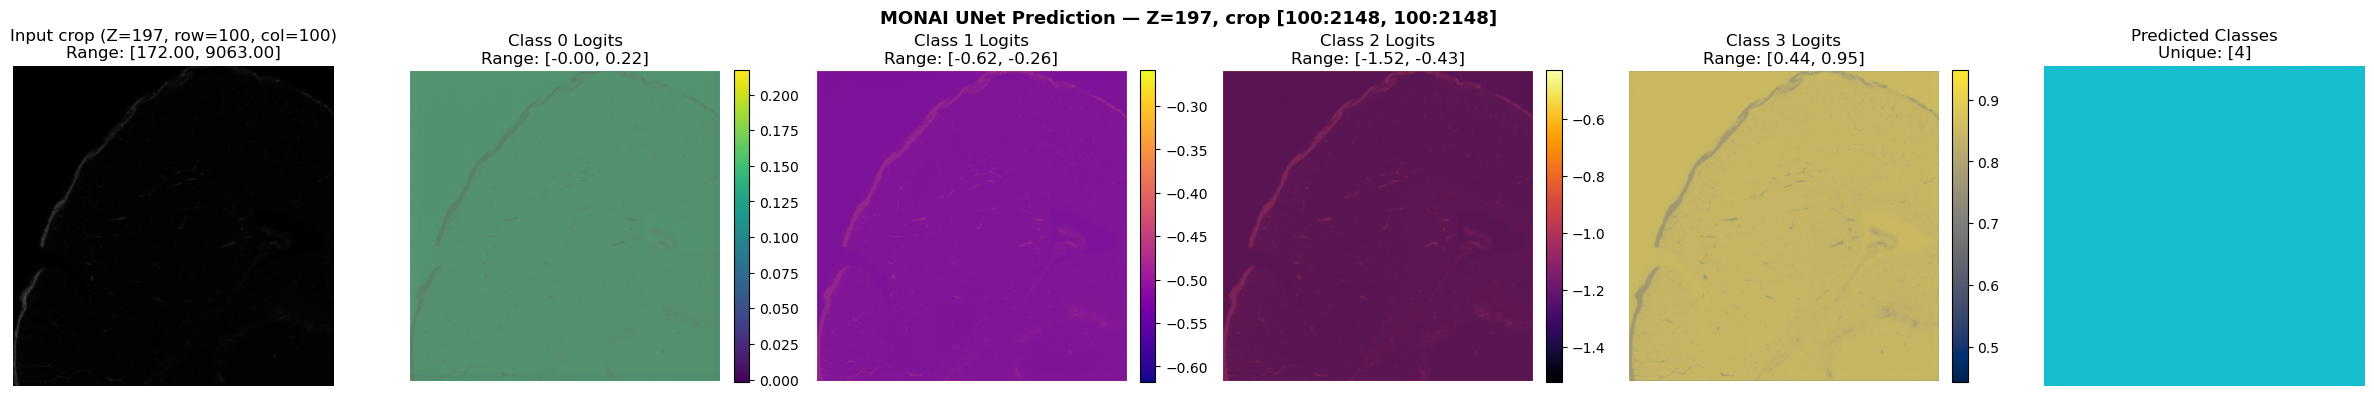

✅ Visualization complete!


In [5]:
# Visualize: Input slice | Class logits | Predicted classes
num_cols = 1 + num_classes + 1  # Input + one per class + Predicted
fig, axes = plt.subplots(1, num_cols, figsize=(4 * num_cols, 4))

col = 0

# Input crop
axes[col].imshow(cropped_slice, cmap='gray')
axes[col].set_title(f'Input crop (Z={mid_z}, row={crop_row}, col={crop_col})\nRange: [{cropped_slice.min():.2f}, {cropped_slice.max():.2f}]')
axes[col].axis('off')
col += 1

# Logits per class
colors_cmap = ['viridis', 'plasma', 'inferno', 'cividis', 'magma']
for class_idx in range(num_classes):
    class_logits = logits[class_idx]
    im = axes[col].imshow(class_logits, cmap=colors_cmap[class_idx % len(colors_cmap)])
    axes[col].set_title(f'Class {class_idx} Logits\nRange: [{class_logits.min():.2f}, {class_logits.max():.2f}]')
    axes[col].axis('off')
    plt.colorbar(im, ax=axes[col], fraction=0.046, pad=0.04)
    col += 1

# Predicted classes
axes[col].imshow(predicted_classes, cmap='tab10', vmin=0, vmax=num_classes)
axes[col].set_title(f'Predicted Classes\nUnique: {np.unique(predicted_classes)}')
axes[col].axis('off')

plt.suptitle(f'MONAI UNet Prediction — Z={mid_z}, crop [{crop_row}:{crop_row+crop_size}, {crop_col}:{crop_col+crop_size}]', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Visualization complete!")


In [17]:
import napari

viewer = napari.Viewer()
viewer.add_image(cropped_slice, name='Input Crop', colormap='gray')
viewer.add_labels(predicted_classes, name='Predicted Classes', opacity=0.5, blending='additive')

<Labels layer 'Predicted Classes' at 0x28e00aea450>

0.0 0.8888685284774253
0 4 [0 1 2 3 4]


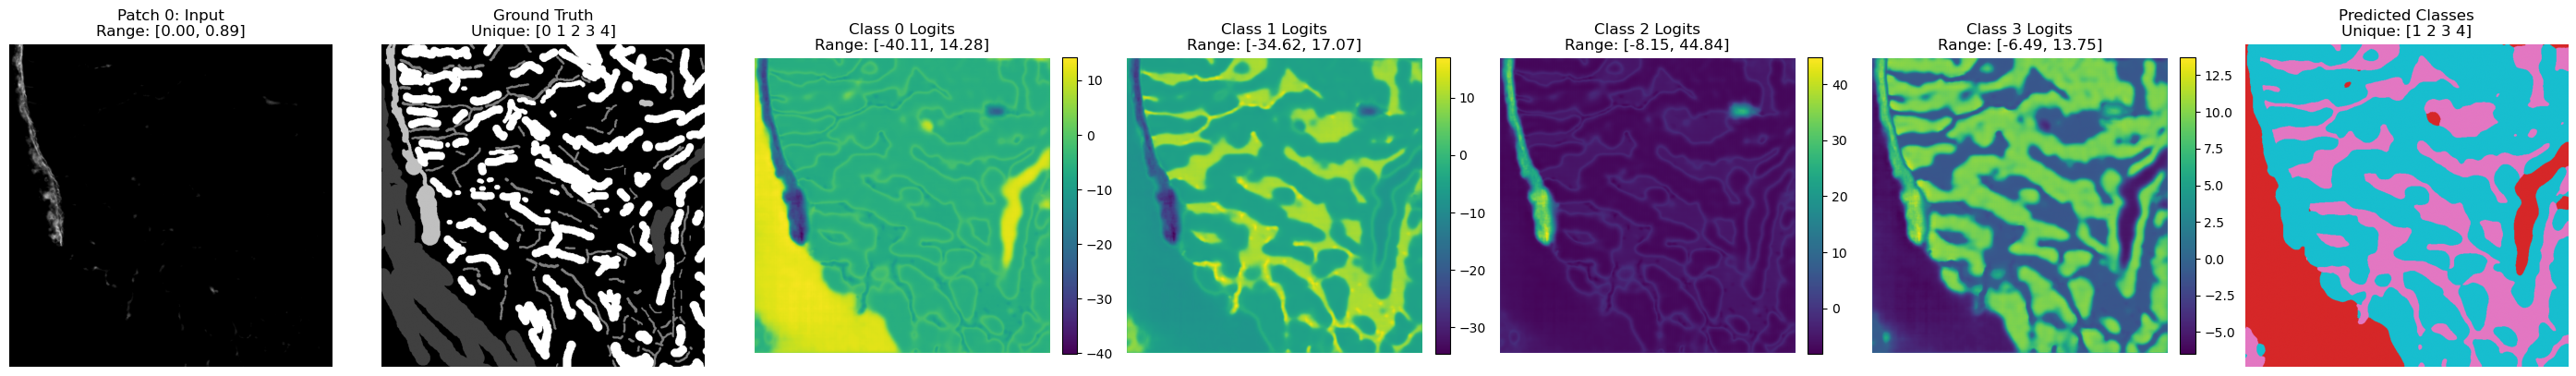

✅ Visualization complete!


In [ ]:
import tifffile

# Predict and visualize 5 patches with class logits
# Get number of classes from the model
segmenter.num_classes = 4
num_classes = segmenter.num_classes

# Create figure: Input | Ground Truth | Class 0 logits | Class 1 logits | Class 2 logits | ...
num_cols = 2 + num_classes + 1  # Input + Truth + one column per class + Predicted Classes
fig, axes = plt.subplots(1, num_cols, figsize=(4*num_cols, 4*1))

patches_dir = image_data_model.get_patches_directory(axis="yx")
inputs_dir = patches_dir / 'input0'
truth_dir = patches_dir / 'ground_truth0'
patch_files = sorted(inputs_dir.rglob("*.tif"))
truth_files = sorted(truth_dir.rglob("*.tif"))
# Load patch and ground truth
patch_path = patch_files[0]
truth_path = truth_files[0]

patch = tifffile.imread(patch_path)
truth = tifffile.imread(truth_path)

print(patch.min(), patch.max())
print(truth.min(), truth.max(), np.unique(truth))

# Get logits for each class
logits, predicted_classes = simple_predict_logits(segmenter.model, patch, device=device)


col = 0

# Display input
axes[col].imshow(patch, cmap='gray')
axes[col].set_title(f'Patch 0: Input\nRange: [{patch.min():.2f}, {patch.max():.2f}]')
axes[col].axis('off')
col += 1

# Display ground truth
axes[col].imshow(truth, cmap='gray')
axes[col].set_title(f'Ground Truth\nUnique: {np.unique(truth)}')
axes[col].axis('off')
col += 1

# Display logits for each class
for class_idx in range(num_classes):
    class_logits = logits[class_idx]
    im = axes[col].imshow(class_logits, cmap='viridis')
    axes[col].set_title(f'Class {class_idx} Logits\nRange: [{class_logits.min():.2f}, {class_logits.max():.2f}]')
    axes[col].axis('off')
    plt.colorbar(im, ax=axes[col], fraction=0.046, pad=0.04)
    col += 1

# Display predicted classes
axes[col].imshow(predicted_classes, cmap='tab10', vmin=0, vmax=num_classes-1)
axes[col].set_title(f'Predicted Classes\nUnique: {np.unique(predicted_classes)}')
axes[col].axis('off')


plt.tight_layout()
plt.show()

print("✅ Visualization complete!")